# YOLO Direct Detection Visualization

This notebook uses the Ultralytics YOLO package directly (no wrapper) to visualize detections.
It mirrors the image selection used in `yolo_detect_viz.ipynb`.

Run top-to-bottom. It uses settings from `app/core/config.py`.


In [1]:
import sys
from pathlib import Path
from typing import List

from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

ROOT = Path('/workspace/PoC/dogface_fastapi_poc_qdrant')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)


ROOT: /workspace/PoC/dogface_fastapi_poc_qdrant


In [2]:
from app.core.config import settings
from ultralytics import YOLO

def parse_class_ids(s: str) -> List[int]:
    out = []
    for part in (s or '').split(','):
        part = part.strip()
        if not part:
            continue
        out.append(int(part))
    return out

keep_ids = parse_class_ids(settings.yolo_class_ids) if settings.yolo_class_ids else None
weights_path = Path('/workspace/PoC/dogface_fastapi_poc_qdrant/weights/yolo/yolo26x.pt')
task = settings.yolo_task

model = YOLO(str(weights_path), task=task)

print('YOLO weights:', weights_path)
print('device:', settings.device)
print('task:', task)
print('imgsz/conf/iou:', settings.yolo_imgsz, settings.yolo_conf, settings.yolo_iou)
print('keep_class_ids:', keep_ids)


YOLO weights: /workspace/PoC/dogface_fastapi_poc_qdrant/weights/yolo/yolo26x.pt
device: cuda:0
task: detect
imgsz/conf/iou: 640 0.25 0.45
keep_class_ids: [15, 16]


In [3]:
def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def load_image(path: Path):
    try:
        return Image.open(path).convert('RGB')
    except UnidentifiedImageError:
        return None

def collect_images(dirs, exts=None, limit=12):
    exts = exts or {'.jpg', '.jpeg', '.png'}
    paths = []
    for d in dirs:
        if not d.exists():
            continue
        for p in d.rglob('*'):
            if p.suffix.lower() in exts:
                paths.append(p)
    return paths[:limit]

def show_grid(images, cols=3, title=''):
    if not images:
        print('No images')
        return
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = [ax for row in axes for ax in row]
    for ax, im in zip(axes, images):
        ax.imshow(im)
        ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.show()


In [4]:
IMAGE_DIRS = [
    Path('/workspace/PoC/petface_yolov8n_pose/notebooks/for_test'),
    Path('/workspace/PoC/petface_yolov8n_pose/notebooks/facebank'),
]

sample_paths = collect_images(IMAGE_DIRS, limit=12)
sample_paths = [p for p in sample_paths if is_valid_image(p)]
print('sample count:', len(sample_paths))
for p in sample_paths[:5]:
    print(p)

images = [load_image(p) for p in sample_paths]
images = [img for img in images if img is not None]


sample count: 11
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/sample_5m_ago.png
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/Biggles_1.jpg
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/2.png
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/Biggles_0.jpg
/workspace/PoC/petface_yolov8n_pose/notebooks/for_test/red_0.png


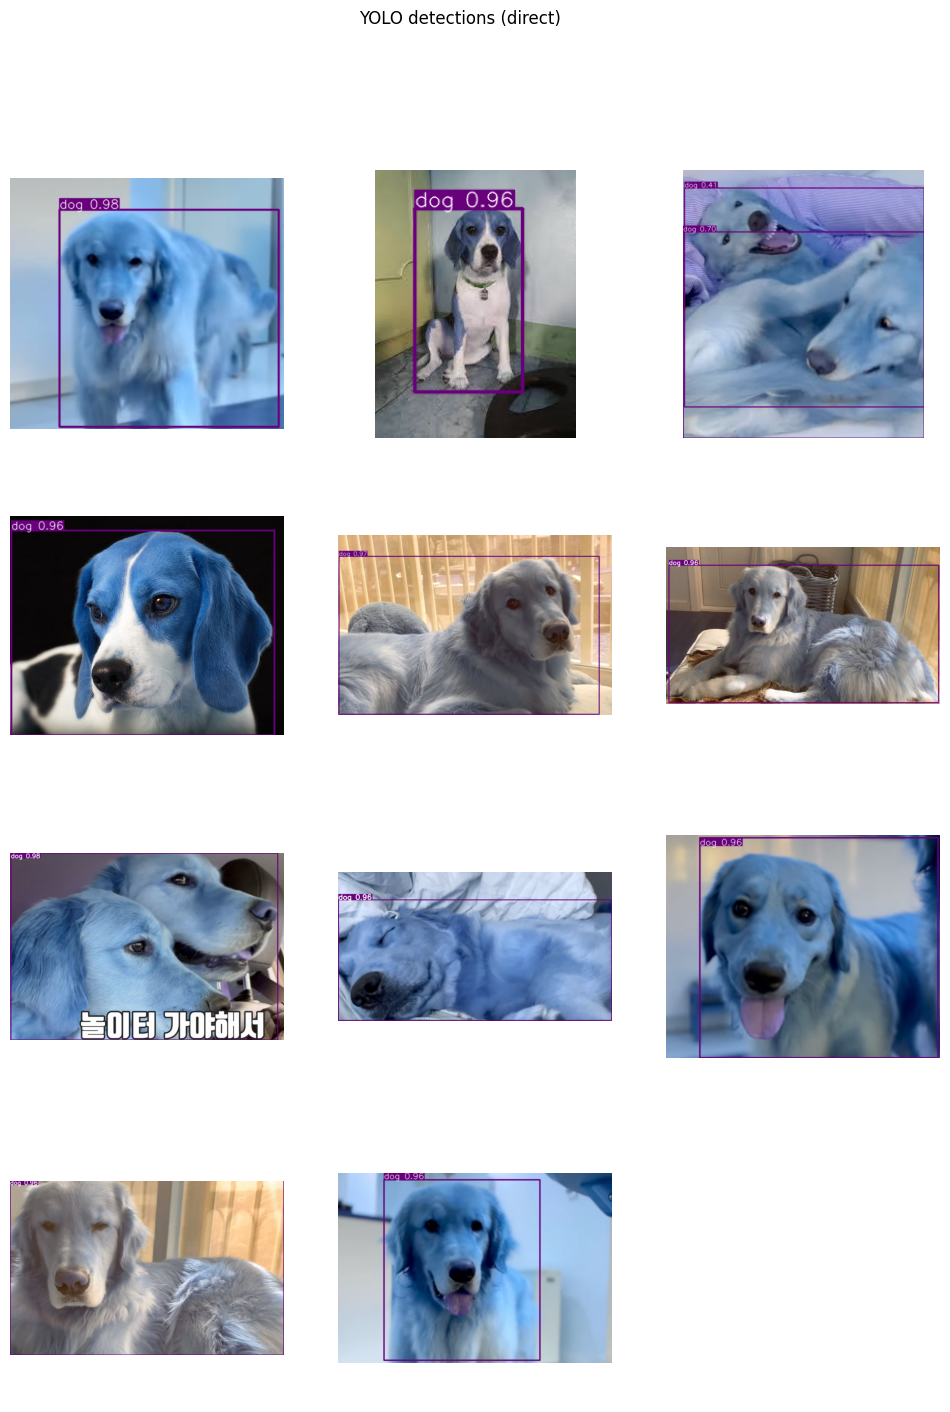

In [5]:
vis = []
for img in images:
    results = model.predict(
        source=img,
        imgsz=settings.yolo_imgsz,
        conf=settings.yolo_conf,
        iou=settings.yolo_iou,
        device=settings.device,
        classes=keep_ids,
        verbose=False,
    )
    if not results:
        continue
    rendered = results[0].plot()
    vis.append(Image.fromarray(rendered))

show_grid(vis, cols=3, title='YOLO detections (direct)')
